In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def plot_performance_vs_hdiv(
    performance_dict,
    hdiv_dict,
    title="Segmentation performance vs H-divergence",
    xlabel="PAD",
    ylabel="Performance (F1-score)",
    colors=None,
    markers=None,
    figsize=(10, 7),
    fontsize=20,
    point_size=150,
    save_path="/g/kreshuk/talks/model_ranking/notebooks/thesis/mitochondria/figures",
    save_name="performance_vs_hdiv",
):
    """Scatter-plot segmentation performance against repeated h-divergence values."""
    shared_datasets = [dataset for dataset in performance_dict if dataset in hdiv_dict]
    if not shared_datasets:
        raise ValueError("No overlapping datasets found between performance and hdiv dictionaries.")

    if colors is None:
        colors = {
            "EPFL": "#4C78A8",
            "Hmito": "#F58518",
            "Rmito": "#54A24B",
            "VNC": "#C44E52",
        }
    if markers is None:
        markers = {
            "EPFL": "^",
            "Hmito": "o",
            "Rmito": "s",
            "VNC": "D",
        }

    fig, ax = plt.subplots(figsize=figsize)

    for dataset in shared_datasets:
        hdiv_values = list(hdiv_dict[dataset])
        if not isinstance(hdiv_values, (list, tuple)):
            raise ValueError(f"H-divergence values for {dataset} must be a list or tuple.")

        x_values = list(hdiv_values)
        y_values = list(performance_dict[dataset])
        _= ax.scatter(
            x_values,
            y_values,
            s=point_size,
            color=colors.get(dataset, None),
            marker=markers.get(dataset, "o"),
            edgecolor="black",
            linewidth=0.6,
            label=dataset,
        )

    _ =ax.set_xlabel(xlabel, fontsize=fontsize)
    _ =ax.set_ylabel(ylabel, fontsize=fontsize)
    _ =ax.set_title(title, fontsize=fontsize)
    _ =ax.grid(True, linestyle="--", alpha=0.35)
    _ =ax.legend(frameon=False, loc="best", fontsize=fontsize - 2)
    _ =ax.tick_params(axis="both", labelsize=fontsize - 2)

    plt.tight_layout()
    plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches=None)
    plt.show()

In [3]:
def get_result_path(source: str, target: str, id: int, save_name_postfix: str, consistency_type: str = 'SVM'):
    data_path = f"/g/kreshuk/talks/domain_gap/experiments/patch_classification/{source}_to_{target}/{consistency_type}/predictions/{source}_to_{target}_{save_name_postfix}_{id}.npz"
    return data_path

In [4]:
def get_domain_gap_preds(source: str, target: str, num_repeats: int, save_name_postfix: str = "SVM_pred", start_id: int = 0):
    f1_scores = np.zeros(num_repeats)
    Hdiv_scores = np.zeros(num_repeats)
    pred_error = np.zeros(num_repeats)
    for i in range(num_repeats):
        data_path = get_result_path(source, target, i+start_id, save_name_postfix)
        with np.load(data_path, "r") as f:
            f1_scores[i] = f['f1']
            Hdiv_scores[i] = f['h_divergence']
            pred_error[i] = f['model_pred_error']
    return Hdiv_scores, f1_scores, pred_error

In [5]:
def number_points(x,y):
    for i in range(x.shape[0]):
        plt.text(x[i], y[i], str(i))

In [6]:
epfl_hdiv_10k, epfl_f1_10k, epfl_err_10k = get_domain_gap_preds("Rmito", "epfl", 5, "10k")
VNC_hdiv_10k, VNC_f1_10k, VNC_err_10k = get_domain_gap_preds("Rmito", "VNC", 5, "10k")
Hmito_hdiv_10k, Hmito_f1_10k, Hmito_err_10k = get_domain_gap_preds("Rmito", "Hmito", 5, "10k")
Rmito_hdiv_10k, Rmito_f1_10k, Rmito_err_10k = get_domain_gap_preds("Rmito", "Rmito", 5, "10k")

In [7]:
Rmito_hdiv = {
    "EPFL": epfl_hdiv_10k,
    "Hmito": Hmito_hdiv_10k,
    "Rmito": Rmito_hdiv_10k,
    "VNC": VNC_hdiv_10k
}

Rmito_f1 = {
    "EPFL": epfl_f1_10k,
    "Hmito": Hmito_f1_10k,
    "Rmito": Rmito_f1_10k,
    "VNC": VNC_f1_10k
}

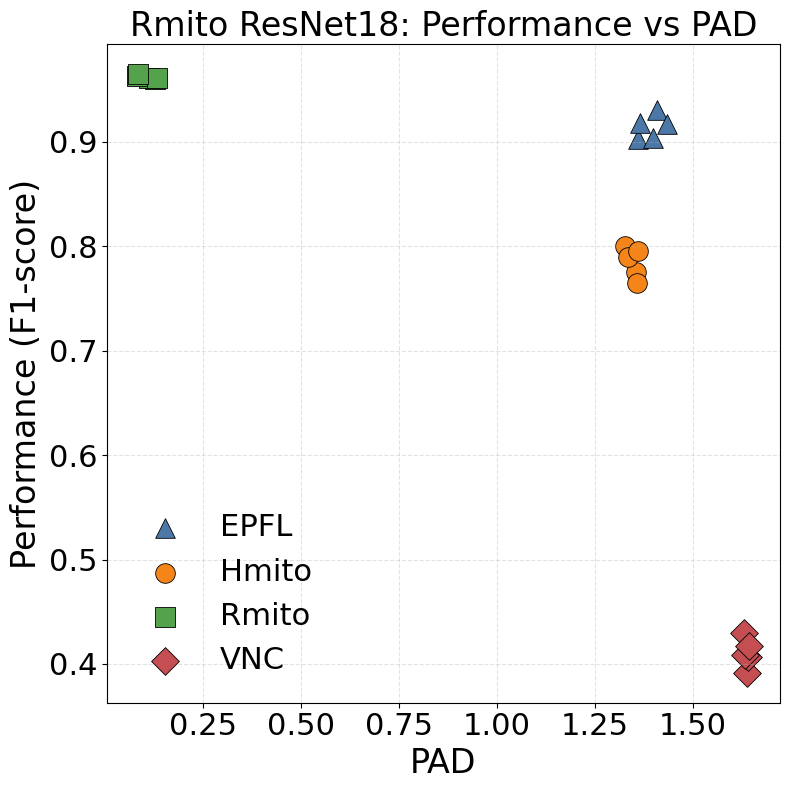

In [8]:
plot_performance_vs_hdiv(
    Rmito_f1,
    Rmito_hdiv,
    title="Rmito ResNet18: Performance vs PAD",
    save_name="Rmito_RN18_perf_vs_hdiv_square",
    figsize=(8, 8),
    fontsize=24,
    point_size=200
)

In [9]:
EtoE_hdiv_10k, EtoE_f1_10k, EtoE_err_10k = get_domain_gap_preds("epfl", "epfl", 5, "10k")
EtoR_hdiv_10k, EtoR_f1_10k, EtoR_err_10k = get_domain_gap_preds("epfl", "Rmito", 5, "10k")
EtoV_hdiv_10k, EtoV_f1_10k, EtoV_err_10k = get_domain_gap_preds("epfl", "VNC", 5, "10k")
EtoH_hdiv_10k, EtoH_f1_10k, EtoH_err_10k = get_domain_gap_preds("epfl", "Hmito", 5, "10k")

In [10]:
EPFL_hdiv = {
    "EPFL": EtoE_hdiv_10k,
    "Hmito": EtoH_hdiv_10k,
    "Rmito": EtoR_hdiv_10k,
    "VNC": EtoV_hdiv_10k
}

EPFL_f1 = {
    "EPFL": EtoE_f1_10k,
    "Hmito": EtoH_f1_10k,
    "Rmito": EtoR_f1_10k,
    "VNC": EtoV_f1_10k
}

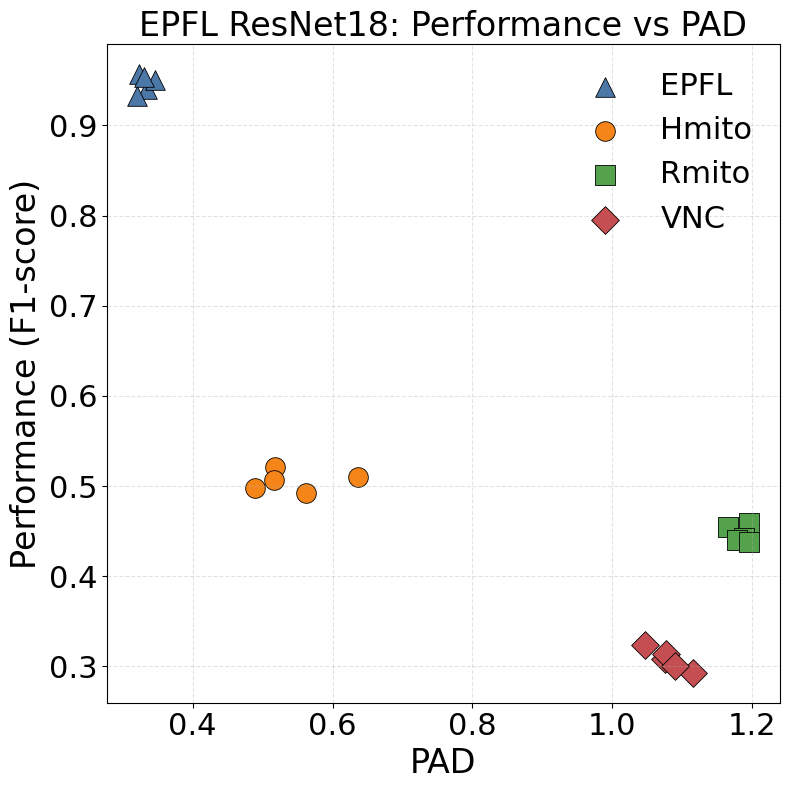

In [11]:
plot_performance_vs_hdiv(
    EPFL_f1,
    EPFL_hdiv,
    title="EPFL ResNet18: Performance vs PAD",
    save_name="EPFL_RN18_perf_vs_hdiv_square",
    figsize=(8, 8),
    fontsize=24,
    point_size=200
)